In [1]:
# ============================================================
# PHASE 17 — ROBUST REPEATED CROSS-VALIDATION EVALUATION
# ============================================================
# Purpose:
# Strengthen statistical reliability beyond a single held-out split.
#
# This phase performs repeated stratified k-fold evaluation for:
# 1. Genomic-only K3/K4/Basic
# 2. Protein-only ProtBERT-SW
# 3. Handcrafted multimodal
# 4. DNABERT-2 multimodal
#
# Main outputs:
# - repeated CV metrics
# - mean ± SD and 95% CI
# - paired statistical tests
# - model ranking stability
# - manuscript-ready figures
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)
from scipy.stats import wilcoxon, ttest_rel, binomtest
from statsmodels.stats.multitest import multipletests

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 300)

RANDOM_SEED = 42

import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

PHASE3_DIR = PROJECT_DIR / "model" / "phase3_multimodal_integration"
SHARED_DIR = PHASE3_DIR / "shared_dataset"

PHASE17_DIR = PROJECT_DIR / "model" / "phase17_repeated_cross_validation_robust_benchmark"
RESULT_DIR = PHASE17_DIR / "results"
FIGURE_DIR = PHASE17_DIR / "figures"
MODEL_DIR = PHASE17_DIR / "models"
EXCEL_DIR = PHASE17_DIR / "excel"
REPORT_DIR = PHASE17_DIR / "reports"

for d in [PHASE17_DIR, RESULT_DIR, FIGURE_DIR, MODEL_DIR, EXCEL_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Phase 17 output:", PHASE17_DIR)

Mounted at /content/drive
Phase 17 output: /content/drive/MyDrive/Project_Protein/model/phase17_repeated_cross_validation_robust_benchmark


In [2]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def load_npy_required(path):
    path = Path(path)
    assert path.exists(), f"Missing required file: {path}"
    arr = np.load(path, allow_pickle=True)
    print("Loaded:", path, arr.shape)
    return arr


def save_df(df, path):
    path = Path(path)
    df.to_csv(path, index=False)
    print("Saved:", path)


def round_numeric_columns(df, digits=4):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].round(digits)
    return df


def choose_threshold_by_mcc(y_true, y_score, n_grid=501):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)

    qs = np.linspace(0, 1, n_grid)
    thresholds = np.quantile(y_score, qs)
    thresholds = np.unique(thresholds)

    best_thr = thresholds[0]
    best_mcc = -999

    for thr in thresholds:
        pred = (y_score >= thr).astype(int)
        mcc = matthews_corrcoef(y_true, pred)

        if mcc > best_mcc:
            best_mcc = mcc
            best_thr = thr

    return float(best_thr), float(best_mcc)


def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        return proba[:, 1]

    if hasattr(model, "decision_function"):
        return model.decision_function(X)

    pred = model.predict(X)
    return pred


def evaluate_prediction(y_true, y_score, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)
    y_pred = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "threshold": threshold
    }


def bootstrap_ci_mean(values, n_boot=5000, seed=42, ci=95):
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)
    boots = []

    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        boots.append(np.mean(sample))

    alpha = (100 - ci) / 2
    low = np.percentile(boots, alpha)
    high = np.percentile(boots, 100 - alpha)

    return float(low), float(high)


def build_model(model_type):
    """
    Conservative models to avoid excessive compute.
    Main goal is robust comparison, not hyperparameter hunting.
    """

    if model_type == "svm_rbf":
        return Pipeline([
            ("variance", VarianceThreshold()),
            ("scaler", StandardScaler()),
            ("model", SVC(
                C=1.0,
                gamma="scale",
                kernel="rbf",
                probability=True,
                class_weight="balanced",
                random_state=RANDOM_SEED
            ))
        ])

    if model_type == "logistic":
        return Pipeline([
            ("variance", VarianceThreshold()),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                C=0.1,
                penalty="l2",
                solver="liblinear",
                class_weight="balanced",
                random_state=RANDOM_SEED,
                max_iter=5000
            ))
        ])

    if model_type == "random_forest":
        return Pipeline([
            ("variance", VarianceThreshold()),
            ("model", RandomForestClassifier(
                n_estimators=500,
                max_depth=10,
                min_samples_leaf=5,
                max_features="sqrt",
                class_weight="balanced",
                random_state=RANDOM_SEED,
                n_jobs=-1
            ))
        ])

    raise ValueError(f"Unknown model_type: {model_type}")


def paired_tests(df, model_a, model_b, metrics):
    """
    Compare model_a - model_b over paired folds.
    """

    records = []

    for metric in metrics:
        a = df[df["model_name"] == model_a].sort_values("split_id")[metric].values
        b = df[df["model_name"] == model_b].sort_values("split_id")[metric].values

        assert len(a) == len(b), f"Unequal paired length for {metric}"
        delta = a - b

        try:
            w = wilcoxon(delta)
            wilcoxon_p = w.pvalue
        except Exception:
            wilcoxon_p = np.nan

        try:
            t = ttest_rel(a, b)
            paired_t_p = t.pvalue
        except Exception:
            paired_t_p = np.nan

        n_wins = int(np.sum(delta > 0))
        n_losses = int(np.sum(delta < 0))
        n_ties = int(np.sum(delta == 0))

        try:
            sign_p = binomtest(
                k=n_wins,
                n=n_wins + n_losses,
                p=0.5,
                alternative="two-sided"
            ).pvalue if (n_wins + n_losses) > 0 else np.nan
        except Exception:
            sign_p = np.nan

        ci_low, ci_high = bootstrap_ci_mean(delta, seed=RANDOM_SEED)

        records.append({
            "comparison": f"{model_a} minus {model_b}",
            "model_a": model_a,
            "model_b": model_b,
            "metric": metric,
            "mean_delta": np.mean(delta),
            "sd_delta": np.std(delta, ddof=1),
            "ci95_low": ci_low,
            "ci95_high": ci_high,
            "n_pairs": len(delta),
            "wins_model_a": n_wins,
            "wins_model_b": n_losses,
            "ties": n_ties,
            "wilcoxon_p": wilcoxon_p,
            "paired_t_p": paired_t_p,
            "sign_test_p": sign_p
        })

    out = pd.DataFrame(records)

    valid = out["wilcoxon_p"].notna()
    out["wilcoxon_bh_fdr"] = np.nan
    if valid.sum() > 0:
        out.loc[valid, "wilcoxon_bh_fdr"] = multipletests(
            out.loc[valid, "wilcoxon_p"],
            method="fdr_bh"
        )[1]

    return out

In [3]:
# ============================================================
# LOAD SHARED DATASETS
# ============================================================

SHARED_DIR = PHASE3_DIR / "features"
PHASE5_DIR1 = PROJECT_DIR / "model" / "phase5_dnabert2_genomic_foundation"
SHARED_DIR1 = PHASE5_DIR1 / "embeddings"
SHARED_DIR2 = PHASE3_DIR / "shared_dataset"

# Protein
X_train_protein = load_npy_required(SHARED_DIR / "X_train_protein_protbert_sw_v1.npy")
X_val_protein   = load_npy_required(SHARED_DIR / "X_val_protein_protbert_sw_v1.npy")
X_test_protein  = load_npy_required(SHARED_DIR / "X_test_protein_protbert_sw_v1.npy")

# Handcrafted multimodal: ProtBERT + K3/K4/Basic
X_train_hand = load_npy_required(SHARED_DIR / "X_train_combined_protein_genomic_v1.npy")
X_val_hand   = load_npy_required(SHARED_DIR / "X_val_combined_protein_genomic_v1.npy")
X_test_hand  = load_npy_required(SHARED_DIR / "X_test_combined_protein_genomic_v1.npy")

# DNABERT-2 multimodal: ProtBERT + DNABERT-2
X_train_dna = load_npy_required(SHARED_DIR1 / "X_train_combined_protbert_sw_dnabert2_v1.npy")
X_val_dna   = load_npy_required(SHARED_DIR1 / "X_val_combined_protbert_sw_dnabert2_v1.npy")
X_test_dna  = load_npy_required(SHARED_DIR1 / "X_test_combined_protbert_sw_dnabert2_v1.npy")

# Labels
y_train = load_npy_required(SHARED_DIR2 / "y_train_multimodal_v1.npy").astype(int)
y_val   = load_npy_required(SHARED_DIR2 / "y_val_multimodal_v1.npy").astype(int)
y_test  = load_npy_required(SHARED_DIR2 / "y_test_multimodal_v1.npy").astype(int)

# Combine old train + val + test into one full shared dataset
X_protein_full = np.vstack([X_train_protein, X_val_protein, X_test_protein])
X_hand_full = np.vstack([X_train_hand, X_val_hand, X_test_hand])
X_dna_full = np.vstack([X_train_dna, X_val_dna, X_test_dna])
y_full = np.concatenate([y_train, y_val, y_test]).astype(int)

PROTEIN_DIM = 1024

X_genomic_full = X_hand_full[:, PROTEIN_DIM:]

print("Full shapes:")
print("Protein:", X_protein_full.shape)
print("Genomic:", X_genomic_full.shape)
print("Handcrafted multimodal:", X_hand_full.shape)
print("DNABERT-2 multimodal:", X_dna_full.shape)
print("Labels:", y_full.shape, np.bincount(y_full))

Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_train_protein_protbert_sw_v1.npy (1264, 1024)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_val_protein_protbert_sw_v1.npy (271, 1024)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_test_protein_protbert_sw_v1.npy (271, 1024)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_train_combined_protein_genomic_v1.npy (1264, 1380)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_val_combined_protein_genomic_v1.npy (271, 1380)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_test_combined_protein_genomic_v1.npy (271, 1380)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase5_dnabert2_genomic_foundation/embeddings/X_train_combined_protbert_sw_dnabert2_v1.npy (1264, 1792

In [4]:
# ============================================================
# FEATURE SETS AND MODEL CONFIGURATIONS
# ============================================================

feature_sets = {
    "Genomic_only_K3K4Basic": {
        "X": X_genomic_full,
        "model_type": "random_forest",
        "display_name": "Genomic-only"
    },
    "Protein_only_ProtBERT_SW": {
        "X": X_protein_full,
        "model_type": "svm_rbf",
        "display_name": "Protein-only"
    },
    "Handcrafted_multimodal": {
        "X": X_hand_full,
        "model_type": "svm_rbf",
        "display_name": "Handcrafted multimodal"
    },
    "DNABERT2_multimodal": {
        "X": X_dna_full,
        "model_type": "svm_rbf",
        "display_name": "DNABERT-2 multimodal"
    }
}

for name, fs in feature_sets.items():
    print(name, fs["X"].shape, fs["model_type"])

Genomic_only_K3K4Basic (1806, 356) random_forest
Protein_only_ProtBERT_SW (1806, 1024) svm_rbf
Handcrafted_multimodal (1806, 1380) svm_rbf
DNABERT2_multimodal (1806, 1792) svm_rbf


In [5]:
# ============================================================
# REPEATED STRATIFIED K-FOLD CV
# ============================================================
# Recommended:
# n_splits = 5
# n_repeats = 5 gives 25 paired evaluations.
#
# If Colab is slow:
# start with n_repeats = 2, then increase to 5.
# ============================================================

N_SPLITS = 5
N_REPEATS = 5

cv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_SEED
)

cv_records = []
prediction_records = []

split_id = 0

for train_val_idx, test_idx in cv.split(X_hand_full, y_full):
    split_id += 1

    print("=" * 100)
    print(f"Split {split_id}/{N_SPLITS * N_REPEATS}")

    y_train_val = y_full[train_val_idx]
    y_fold_test = y_full[test_idx]

    # Inner validation split from train_val
    # We use simple stratified split by taking 20% from train_val via another fold-like split
    inner_cv = RepeatedStratifiedKFold(
        n_splits=5,
        n_repeats=1,
        random_state=RANDOM_SEED + split_id
    )

    inner_train_rel, inner_val_rel = next(inner_cv.split(np.zeros(len(train_val_idx)), y_train_val))

    train_idx = train_val_idx[inner_train_rel]
    val_idx = train_val_idx[inner_val_rel]

    for model_name, fs in feature_sets.items():
        print("Model:", model_name)

        X = fs["X"]
        X_fold_train = X[train_idx]
        X_fold_val = X[val_idx]
        X_fold_test = X[test_idx]

        y_fold_train = y_full[train_idx]
        y_fold_val = y_full[val_idx]

        model = build_model(fs["model_type"])
        model.fit(X_fold_train, y_fold_train)

        val_score = get_scores(model, X_fold_val)
        threshold, val_mcc = choose_threshold_by_mcc(y_fold_val, val_score)

        test_score = get_scores(model, X_fold_test)
        metrics = evaluate_prediction(y_fold_test, test_score, threshold)

        rec = {
            "split_id": split_id,
            "outer_n_splits": N_SPLITS,
            "outer_n_repeats": N_REPEATS,
            "model_name": model_name,
            "display_name": fs["display_name"],
            "model_type": fs["model_type"],
            "n_train": len(train_idx),
            "n_val": len(val_idx),
            "n_test": len(test_idx),
            "n_features": X.shape[1],
            "validation_mcc": val_mcc,
            **metrics
        }

        cv_records.append(rec)

        # Save predictions for ranking utility later
        for local_i, global_i in enumerate(test_idx):
            prediction_records.append({
                "split_id": split_id,
                "model_name": model_name,
                "sample_index": int(global_i),
                "true_label": int(y_full[global_i]),
                "score": float(test_score[local_i]),
                "threshold": float(threshold),
                "pred_label": int(test_score[local_i] >= threshold)
            })

cv_results_df = pd.DataFrame(cv_records)
cv_predictions_df = pd.DataFrame(prediction_records)

cv_results_df = round_numeric_columns(cv_results_df, 5)

display(cv_results_df.head())
display(cv_results_df.groupby("model_name").size())

save_df(cv_results_df, RESULT_DIR / "phase17_repeated_cv_all_fold_metrics.csv")
save_df(cv_predictions_df, RESULT_DIR / "phase17_repeated_cv_all_predictions.csv")

Split 1/25
Model: Genomic_only_K3K4Basic
Model: Protein_only_ProtBERT_SW
Model: Handcrafted_multimodal
Model: DNABERT2_multimodal
Split 2/25
Model: Genomic_only_K3K4Basic
Model: Protein_only_ProtBERT_SW
Model: Handcrafted_multimodal
Model: DNABERT2_multimodal
Split 3/25
Model: Genomic_only_K3K4Basic
Model: Protein_only_ProtBERT_SW
Model: Handcrafted_multimodal
Model: DNABERT2_multimodal
Split 4/25
Model: Genomic_only_K3K4Basic
Model: Protein_only_ProtBERT_SW
Model: Handcrafted_multimodal
Model: DNABERT2_multimodal
Split 5/25
Model: Genomic_only_K3K4Basic
Model: Protein_only_ProtBERT_SW
Model: Handcrafted_multimodal
Model: DNABERT2_multimodal
Split 6/25
Model: Genomic_only_K3K4Basic
Model: Protein_only_ProtBERT_SW
Model: Handcrafted_multimodal
Model: DNABERT2_multimodal
Split 7/25
Model: Genomic_only_K3K4Basic
Model: Protein_only_ProtBERT_SW
Model: Handcrafted_multimodal
Model: DNABERT2_multimodal
Split 8/25
Model: Genomic_only_K3K4Basic
Model: Protein_only_ProtBERT_SW
Model: Handcrafte

,split_id,outer_n_splits,outer_n_repeats,model_name,display_name,model_type,n_train,n_val,n_test,n_features,validation_mcc,roc_auc,pr_auc,accuracy,precision,recall,specificity,f1,mcc,tn,fp,fn,tp,threshold
0,1,5,5,Genomic_only_K3K4Basic,Genomic-only,random_forest,1155,289,362,356,0.22809,0.62584,0.65037,0.58840,0.65094,0.38122,0.79558,0.48084,0.19426,144,37,112,69,0.54426
1,1,5,5,Protein_only_ProtBERT_SW,Protein-only,svm_rbf,1155,289,362,1024,0.31741,0.72748,0.70890,0.66022,0.71642,0.53039,0.79006,0.60952,0.33182,143,38,85,96,0.60088
2,1,5,5,Handcrafted_multimodal,Handcrafted multimodal,svm_rbf,1155,289,362,1380,0.32242,0.74261,0.72493,0.69613,0.69613,0.69613,0.69613,0.69613,0.39227,126,55,55,126,0.51393
3,1,5,5,DNABERT2_multimodal,DNABERT-2 multimodal,svm_rbf,1155,289,362,1792,0.37537,0.75320,0.74304,0.68785,0.77869,0.52486,0.85083,0.62706,0.39740,154,27,86,95,0.61168
4,2,5,5,Genomic_only_K3K4Basic,Genomic-only,random_forest,1156,289,361,356,0.39814,0.59334,0.57461,0.56510,0.57616,0.48333,0.64641,0.52568,0.13151,117,64,93,87,0.50849


,0
model_name,
DNABERT2_multimodal,25
Genomic_only_K3K4Basic,25
Handcrafted_multimodal,25
Protein_only_ProtBERT_SW,25


Saved: /content/drive/MyDrive/Project_Protein/model/phase17_repeated_cross_validation_robust_benchmark/results/phase17_repeated_cv_all_fold_metrics.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase17_repeated_cross_validation_robust_benchmark/results/phase17_repeated_cv_all_predictions.csv


In [6]:
# ============================================================
# SUMMARY MEAN, SD, 95% CI
# ============================================================

metrics = ["roc_auc", "pr_auc", "mcc", "f1", "accuracy", "precision", "recall", "specificity"]

summary_records = []

for model_name, sub in cv_results_df.groupby("model_name"):
    for metric in metrics:
        values = sub[metric].astype(float).values
        ci_low, ci_high = bootstrap_ci_mean(values, seed=RANDOM_SEED)

        summary_records.append({
            "model_name": model_name,
            "display_name": sub["display_name"].iloc[0],
            "metric": metric,
            "mean": np.mean(values),
            "sd": np.std(values, ddof=1),
            "ci95_low": ci_low,
            "ci95_high": ci_high,
            "n_folds": len(values)
        })

cv_summary_long_df = pd.DataFrame(summary_records)
cv_summary_long_df = round_numeric_columns(cv_summary_long_df, 5)

display(cv_summary_long_df.head(20))

save_df(cv_summary_long_df, RESULT_DIR / "phase17_repeated_cv_summary_long.csv")

# Wide format
cv_summary_wide_df = cv_summary_long_df.pivot_table(
    index=["model_name", "display_name"],
    columns="metric",
    values="mean"
).reset_index()

cv_summary_wide_df = round_numeric_columns(cv_summary_wide_df, 4)

display(cv_summary_wide_df)

save_df(cv_summary_wide_df, RESULT_DIR / "phase17_repeated_cv_summary_wide_mean.csv")

,model_name,display_name,metric,mean,sd,ci95_low,ci95_high,n_folds
0,DNABERT2_multimodal,DNABERT-2 multimodal,roc_auc,0.73059,0.02294,0.72168,0.73917,25
1,DNABERT2_multimodal,DNABERT-2 multimodal,pr_auc,0.71613,0.02381,0.70716,0.72528,25
2,DNABERT2_multimodal,DNABERT-2 multimodal,mcc,0.33084,0.05250,0.31018,0.35048,25
3,DNABERT2_multimodal,DNABERT-2 multimodal,f1,0.64600,0.06639,0.61866,0.67016,25
4,DNABERT2_multimodal,DNABERT-2 multimodal,accuracy,0.66068,0.02802,0.64960,0.67110,25
5,DNABERT2_multimodal,DNABERT-2 multimodal,precision,0.67846,0.05077,0.65957,0.69847,25
6,DNABERT2_multimodal,DNABERT-2 multimodal,recall,0.63837,0.13176,0.58438,0.68750,25
7,DNABERT2_multimodal,DNABERT-2 multimodal,specificity,0.68306,0.11513,0.63946,0.72916,25
8,Genomic_only_K3K4Basic,Genomic-only,roc_auc,0.64082,0.02866,0.62942,0.65126,25
9,Genomic_only_K3K4Basic,Genomic-only,pr_auc,0.64472,0.02863,0.63319,0.65488,25


Saved: /content/drive/MyDrive/Project_Protein/model/phase17_repeated_cross_validation_robust_benchmark/results/phase17_repeated_cv_summary_long.csv


metric,model_name,display_name,accuracy,f1,mcc,pr_auc,precision,recall,roc_auc,specificity
0,DNABERT2_multimodal,DNABERT-2 multimodal,0.6607,0.6460,0.3308,0.7161,0.6785,0.6384,0.7306,0.6831
1,Genomic_only_K3K4Basic,Genomic-only,0.5926,0.5012,0.2034,0.6447,0.6536,0.4328,0.6408,0.7524
2,Handcrafted_multimodal,Handcrafted multimodal,0.6534,0.6330,0.3167,0.7137,0.6765,0.6155,0.7246,0.6912
3,Protein_only_ProtBERT_SW,Protein-only,0.6462,0.6698,0.3078,0.6951,0.6323,0.7352,0.7130,0.5570


Saved: /content/drive/MyDrive/Project_Protein/model/phase17_repeated_cross_validation_robust_benchmark/results/phase17_repeated_cv_summary_wide_mean.csv


In [7]:
# ============================================================
# MANUSCRIPT SUMMARY TABLE
# ============================================================

main_metrics = ["pr_auc", "mcc", "roc_auc", "f1"]

table_records = []

for model_name, sub in cv_results_df.groupby("model_name"):
    rec = {
        "model_name": model_name,
        "display_name": sub["display_name"].iloc[0]
    }

    for metric in main_metrics:
        vals = sub[metric].astype(float).values
        rec[f"{metric}_mean"] = np.mean(vals)
        rec[f"{metric}_sd"] = np.std(vals, ddof=1)

    table_records.append(rec)

manuscript_cv_table_df = pd.DataFrame(table_records)

# Sort by PR-AUC then MCC
manuscript_cv_table_df = manuscript_cv_table_df.sort_values(
    ["pr_auc_mean", "mcc_mean"],
    ascending=False
).reset_index(drop=True)

manuscript_cv_table_df = round_numeric_columns(manuscript_cv_table_df, 4)

display(manuscript_cv_table_df)

save_df(
    manuscript_cv_table_df,
    RESULT_DIR / "phase17_manuscript_repeated_cv_table.csv"
)

,model_name,display_name,pr_auc_mean,pr_auc_sd,mcc_mean,mcc_sd,roc_auc_mean,roc_auc_sd,f1_mean,f1_sd
0,DNABERT2_multimodal,DNABERT-2 multimodal,0.7161,0.0238,0.3308,0.0525,0.7306,0.0229,0.6460,0.0664
1,Handcrafted_multimodal,Handcrafted multimodal,0.7137,0.0193,0.3168,0.0493,0.7247,0.0199,0.6330,0.0627
2,Protein_only_ProtBERT_SW,Protein-only,0.6951,0.0235,0.3078,0.0332,0.7130,0.0199,0.6698,0.0502
3,Genomic_only_K3K4Basic,Genomic-only,0.6447,0.0286,0.2034,0.0432,0.6408,0.0287,0.5011,0.1024


Saved: /content/drive/MyDrive/Project_Protein/model/phase17_repeated_cross_validation_robust_benchmark/results/phase17_manuscript_repeated_cv_table.csv


In [8]:
# ============================================================
# PAIRED STATISTICAL COMPARISONS
# ============================================================

paired_metrics = ["pr_auc", "mcc", "roc_auc", "f1"]

comparison_pairs = [
    ("DNABERT2_multimodal", "Handcrafted_multimodal"),
    ("Handcrafted_multimodal", "Protein_only_ProtBERT_SW"),
    ("DNABERT2_multimodal", "Protein_only_ProtBERT_SW"),
    ("Protein_only_ProtBERT_SW", "Genomic_only_K3K4Basic"),
]

paired_tables = []

for model_a, model_b in comparison_pairs:
    tmp = paired_tests(
        df=cv_results_df,
        model_a=model_a,
        model_b=model_b,
        metrics=paired_metrics
    )
    paired_tables.append(tmp)

paired_stats_df = pd.concat(paired_tables, ignore_index=True)
paired_stats_df = round_numeric_columns(paired_stats_df, 5)

display(paired_stats_df)

save_df(
    paired_stats_df,
    RESULT_DIR / "phase17_repeated_cv_paired_statistical_tests.csv"
)

,comparison,model_a,model_b,metric,mean_delta,sd_delta,ci95_low,ci95_high,n_pairs,wins_model_a,wins_model_b,ties,wilcoxon_p,paired_t_p,sign_test_p,wilcoxon_bh_fdr
0,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,pr_auc,0.00238,0.01815,-0.00489,0.00891,25,16,9,0,0.24107,0.51745,0.22952,0.24107
1,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,mcc,0.01409,0.04589,-0.00362,0.03101,25,16,9,0,0.11993,0.13780,0.22952,0.23987
2,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,roc_auc,0.00593,0.01305,0.00075,0.01068,25,21,4,0,0.02551,0.03232,0.00091,0.10202
3,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,f1,0.01297,0.07340,-0.01580,0.04046,25,14,11,0,0.21999,0.38571,0.69004,0.24107
4,Handcrafted_multimodal minus Protein_only_ProtBERT_SW,Handcrafted_multimodal,Protein_only_ProtBERT_SW,pr_auc,0.01863,0.01643,0.01206,0.02448,25,23,2,0,0.00005,0.00001,0.00002,0.00009
5,Handcrafted_multimodal minus Protein_only_ProtBERT_SW,Handcrafted_multimodal,Protein_only_ProtBERT_SW,mcc,0.00897,0.04205,-0.00832,0.02433,25,15,10,0,0.10731,0.29652,0.42436,0.10731
6,Handcrafted_multimodal minus Protein_only_ProtBERT_SW,Handcrafted_multimodal,Protein_only_ProtBERT_SW,roc_auc,0.01164,0.00910,0.00796,0.01491,25,21,4,0,0.00002,0.00000,0.00091,0.00006
7,Handcrafted_multimodal minus Protein_only_ProtBERT_SW,Handcrafted_multimodal,Protein_only_ProtBERT_SW,f1,-0.03675,0.07491,-0.06599,-0.00798,25,8,17,0,0.01597,0.02180,0.10775,0.02130
8,DNABERT2_multimodal minus Protein_only_ProtBERT_SW,DNABERT2_multimodal,Protein_only_ProtBERT_SW,pr_auc,0.02101,0.02827,0.00970,0.03128,25,21,4,0,0.00163,0.00107,0.00091,0.00325
9,DNABERT2_multimodal minus Protein_only_ProtBERT_SW,DNABERT2_multimodal,Protein_only_ProtBERT_SW,mcc,0.02306,0.05169,0.00273,0.04256,25,15,10,0,0.05875,0.03528,0.42436,0.07834


Saved: /content/drive/MyDrive/Project_Protein/model/phase17_repeated_cross_validation_robust_benchmark/results/phase17_repeated_cv_paired_statistical_tests.csv


In [9]:
# ============================================================
# MODEL RANK STABILITY
# ============================================================

rank_records = []

for metric in paired_metrics:
    for split_id, sub in cv_results_df.groupby("split_id"):
        tmp = sub[["split_id", "model_name", "display_name", metric]].copy()
        tmp["metric"] = metric
        tmp["rank"] = tmp[metric].rank(ascending=False, method="min")
        rank_records.append(tmp)

rank_df = pd.concat(rank_records, ignore_index=True)

rank_summary_df = (
    rank_df
    .groupby(["model_name", "display_name", "metric"], as_index=False)
    .agg(
        mean_rank=("rank", "mean"),
        sd_rank=("rank", "std"),
        n_rank1=("rank", lambda x: int(np.sum(x == 1))),
        n_evaluations=("rank", "count")
    )
)

rank_summary_df = rank_summary_df.sort_values(["metric", "mean_rank"]).reset_index(drop=True)
rank_summary_df = round_numeric_columns(rank_summary_df, 4)

display(rank_summary_df)

save_df(rank_df, RESULT_DIR / "phase17_model_rank_by_split.csv")
save_df(rank_summary_df, RESULT_DIR / "phase17_model_rank_stability_summary.csv")

,model_name,display_name,metric,mean_rank,sd_rank,n_rank1,n_evaluations
0,Protein_only_ProtBERT_SW,Protein-only,f1,1.68,0.7483,12,25
1,DNABERT2_multimodal,DNABERT-2 multimodal,f1,2.16,0.9866,8,25
2,Handcrafted_multimodal,Handcrafted multimodal,f1,2.32,0.8524,5,25
3,Genomic_only_K3K4Basic,Genomic-only,f1,3.84,0.4726,0,25
4,DNABERT2_multimodal,DNABERT-2 multimodal,mcc,1.76,0.8794,13,25
5,Handcrafted_multimodal,Handcrafted multimodal,mcc,2.08,0.7594,5,25
6,Protein_only_ProtBERT_SW,Protein-only,mcc,2.24,0.9256,7,25
7,Genomic_only_K3K4Basic,Genomic-only,mcc,3.92,0.2769,0,25
8,DNABERT2_multimodal,DNABERT-2 multimodal,pr_auc,1.52,0.7703,16,25
9,Handcrafted_multimodal,Handcrafted multimodal,pr_auc,1.72,0.5416,8,25


Saved: /content/drive/MyDrive/Project_Protein/model/phase17_repeated_cross_validation_robust_benchmark/results/phase17_model_rank_by_split.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase17_repeated_cross_validation_robust_benchmark/results/phase17_model_rank_stability_summary.csv


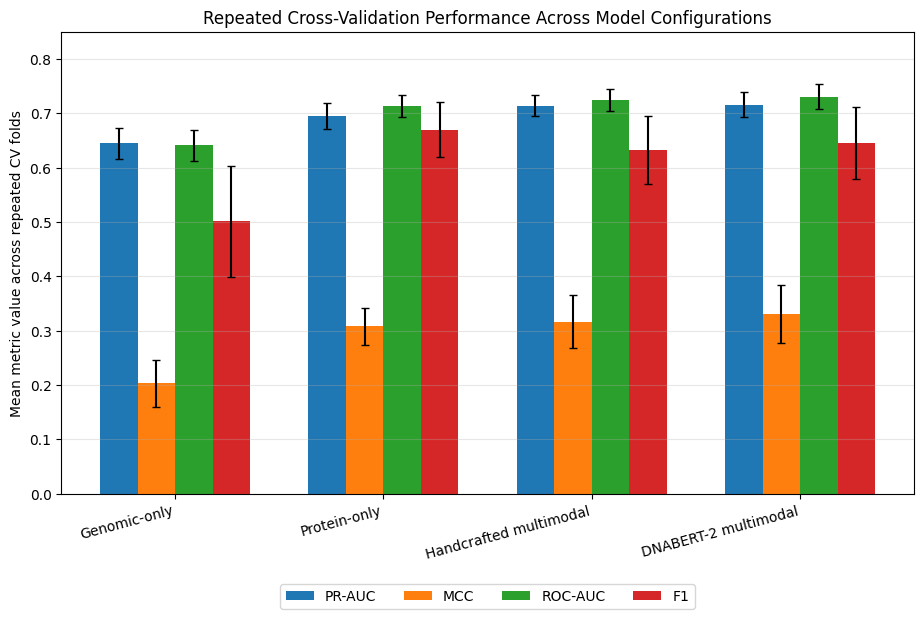

Saved: /content/drive/MyDrive/Project_Protein/model/phase17_repeated_cross_validation_robust_benchmark/figures/phase17_repeated_cv_model_performance.png


In [10]:
# ============================================================
# FIGURE 1 — REPEATED CV PERFORMANCE
# ============================================================

plot_df = manuscript_cv_table_df.copy()

display_order = [
    "Genomic-only",
    "Protein-only",
    "Handcrafted multimodal",
    "DNABERT-2 multimodal"
]

plot_df["display_name"] = pd.Categorical(
    plot_df["display_name"],
    categories=display_order,
    ordered=True
)
plot_df = plot_df.sort_values("display_name")

metrics_plot = [
    ("pr_auc", "PR-AUC"),
    ("mcc", "MCC"),
    ("roc_auc", "ROC-AUC"),
    ("f1", "F1")
]

x = np.arange(len(plot_df))
width = 0.18

plt.figure(figsize=(11, 6))

for i, (metric, label) in enumerate(metrics_plot):
    plt.bar(
        x + (i - 1.5) * width,
        plot_df[f"{metric}_mean"],
        yerr=plot_df[f"{metric}_sd"],
        width=width,
        capsize=3,
        label=label
    )

plt.xticks(x, plot_df["display_name"], rotation=15, ha="right")
plt.ylabel("Mean metric value across repeated CV folds")
plt.title("Repeated Cross-Validation Performance Across Model Configurations")
plt.ylim(0, 0.85)
plt.grid(axis="y", alpha=0.3)
plt.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.18))

out_path = FIGURE_DIR / "phase17_repeated_cv_model_performance.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

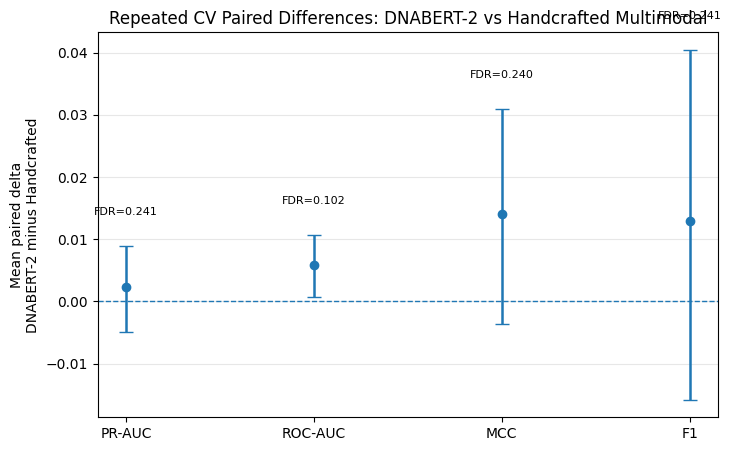

Saved: /content/drive/MyDrive/Project_Protein/model/phase17_repeated_cross_validation_robust_benchmark/figures/phase17_paired_delta_dnabert2_vs_handcrafted.png


In [11]:
# ============================================================
# FIGURE 2 — PAIRED DELTA DNABERT2 VS HANDCRAFTED
# ============================================================

delta_df = paired_stats_df[
    paired_stats_df["comparison"] == "DNABERT2_multimodal minus Handcrafted_multimodal"
].copy()

metric_display_map = {
    "pr_auc": "PR-AUC",
    "mcc": "MCC",
    "roc_auc": "ROC-AUC",
    "f1": "F1"
}

delta_df["metric_display"] = delta_df["metric"].map(metric_display_map)
delta_df = delta_df.set_index("metric").loc[["pr_auc", "roc_auc", "mcc", "f1"]].reset_index()

x = np.arange(len(delta_df))
y = delta_df["mean_delta"].values
err_low = y - delta_df["ci95_low"].values
err_high = delta_df["ci95_high"].values - y

plt.figure(figsize=(8, 5))
plt.errorbar(
    x,
    y,
    yerr=[err_low, err_high],
    fmt="o",
    capsize=5,
    linewidth=1.8
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xticks(x, delta_df["metric_display"])
plt.ylabel("Mean paired delta\nDNABERT-2 minus Handcrafted")
plt.title("Repeated CV Paired Differences: DNABERT-2 vs Handcrafted Multimodal")
plt.grid(axis="y", alpha=0.3)

for i, row in delta_df.iterrows():
    plt.text(
        i,
        row["ci95_high"] + 0.005,
        f"FDR={row['wilcoxon_bh_fdr']:.3f}",
        ha="center",
        fontsize=8
    )

out_path = FIGURE_DIR / "phase17_paired_delta_dnabert2_vs_handcrafted.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

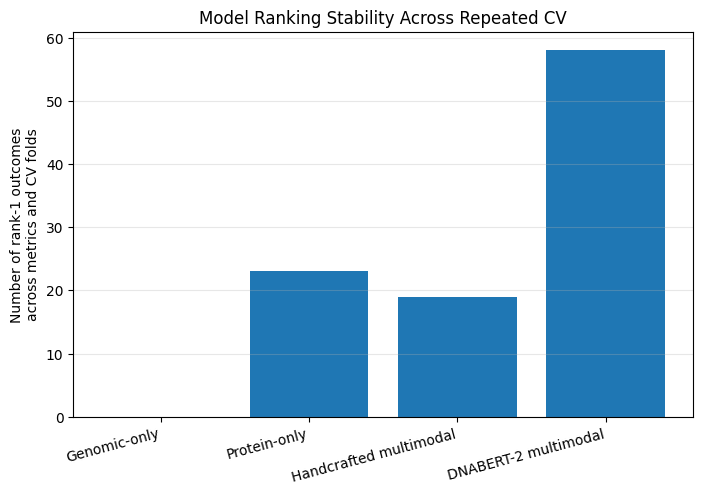

Saved: /content/drive/MyDrive/Project_Protein/model/phase17_repeated_cross_validation_robust_benchmark/figures/phase17_model_rank_stability.png


In [12]:
# ============================================================
# FIGURE 3 — RANK STABILITY
# ============================================================

rank_plot_df = rank_summary_df[rank_summary_df["metric"].isin(["pr_auc", "mcc", "roc_auc", "f1"])].copy()
rank_plot_df["metric_display"] = rank_plot_df["metric"].map(metric_display_map)

# Plot n_rank1 per model aggregated across metrics
rank1_summary = (
    rank_plot_df
    .groupby("display_name", as_index=False)
    .agg(total_rank1=("n_rank1", "sum"))
)

rank1_summary["display_name"] = pd.Categorical(
    rank1_summary["display_name"],
    categories=display_order,
    ordered=True
)
rank1_summary = rank1_summary.sort_values("display_name")

plt.figure(figsize=(8, 5))
plt.bar(rank1_summary["display_name"], rank1_summary["total_rank1"])
plt.ylabel("Number of rank-1 outcomes\nacross metrics and CV folds")
plt.title("Model Ranking Stability Across Repeated CV")
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", alpha=0.3)

out_path = FIGURE_DIR / "phase17_model_rank_stability.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [13]:
# ============================================================
# MANUSCRIPT-READY INTERPRETATION
# ============================================================

# Extract best models by primary metrics
pr_summary = cv_summary_long_df[cv_summary_long_df["metric"] == "pr_auc"].sort_values("mean", ascending=False)
mcc_summary = cv_summary_long_df[cv_summary_long_df["metric"] == "mcc"].sort_values("mean", ascending=False)

best_pr = pr_summary.iloc[0]
best_mcc = mcc_summary.iloc[0]

dnabert_vs_hand = paired_stats_df[
    paired_stats_df["comparison"] == "DNABERT2_multimodal minus Handcrafted_multimodal"
].copy()

text_methods = f"""
To further reduce dependence on a single held-out split, repeated stratified cross-validation was performed on the full shared multimodal dataset. The original training, validation and test partitions were recombined, and {N_REPEATS} repeats of {N_SPLITS}-fold stratified cross-validation were applied, producing {N_REPEATS * N_SPLITS} paired evaluations. Within each outer fold, an inner validation split was used for threshold selection by maximizing MCC, and the selected threshold was applied to the held-out fold. The same fold assignments were used across all model configurations, allowing paired statistical comparison of performance differences.
""".strip()

text_results = f"""
Repeated cross-validation confirmed the overall pattern observed in the held-out evaluation. Protein-containing models consistently outperformed the genomic-only baseline, supporting protein embeddings as the dominant predictive signal. The highest mean PR-AUC was obtained by {best_pr['display_name']} ({best_pr['mean']:.3f} ± {best_pr['sd']:.3f}), while the highest mean MCC was obtained by {best_mcc['display_name']} ({best_mcc['mean']:.3f} ± {best_mcc['sd']:.3f}). Paired tests were used to compare DNABERT-2 multimodal and handcrafted multimodal models across the same folds. These tests provide a more conservative assessment of whether the numerical differences are robust across data partitions.
""".strip()

text_discussion = """
The repeated cross-validation analysis strengthens the reliability of the benchmark by showing whether model behaviour is stable across many paired train-test partitions. This is important because the performance differences among the protein-only, handcrafted multimodal and DNABERT-2 multimodal models are modest. Therefore, the conclusions should emphasize robust trends rather than single-split winners. If DNABERT-2 shows only small or non-significant paired gains, it should remain framed as a ranking extension rather than a clearly superior model. If multimodal models improve MCC or specificity relative to protein-only models, this supports the interpretation that genomic information contributes complementary decision-level signal even when aggregate ranking gains are limited.
""".strip()

wording_df = pd.DataFrame([
    {"section": "Methods - Repeated Cross-Validation", "text": text_methods},
    {"section": "Results - Repeated Cross-Validation", "text": text_results},
    {"section": "Discussion - Robustness Interpretation", "text": text_discussion},
])

display(wording_df)

save_df(wording_df, RESULT_DIR / "phase17_manuscript_ready_wording.csv")

with open(REPORT_DIR / "phase17_manuscript_ready_wording.md", "w") as f:
    for _, row in wording_df.iterrows():
        f.write(f"## {row['section']}\n\n")
        f.write(row["text"] + "\n\n")

print("Saved wording.")

,section,text
0,Methods - Repeated Cross-Validation,"To further reduce dependence on a single held-out split, repeated stratified cross-validation was performed on the full shared multimodal dataset. The original training, validation and test partitions were recombined, and 5 repeats of 5-fold stratified cross-validation were applied, producing 25..."
1,Results - Repeated Cross-Validation,"Repeated cross-validation confirmed the overall pattern observed in the held-out evaluation. Protein-containing models consistently outperformed the genomic-only baseline, supporting protein embeddings as the dominant predictive signal. The highest mean PR-AUC was obtained by DNABERT-2 multimoda..."
2,Discussion - Robustness Interpretation,"The repeated cross-validation analysis strengthens the reliability of the benchmark by showing whether model behaviour is stable across many paired train-test partitions. This is important because the performance differences among the protein-only, handcrafted multimodal and DNABERT-2 multimodal..."


Saved: /content/drive/MyDrive/Project_Protein/model/phase17_repeated_cross_validation_robust_benchmark/results/phase17_manuscript_ready_wording.csv
Saved wording.


In [14]:
# ============================================================
# EXPORT EXCEL WORKBOOK
# ============================================================

excel_path = EXCEL_DIR / "phase17_repeated_cv_robust_benchmark_tables.xlsx"

tables = {
    "All_Fold_Metrics": cv_results_df,
    "All_Predictions": cv_predictions_df,
    "Summary_Long": cv_summary_long_df,
    "Summary_Wide": cv_summary_wide_df,
    "Manuscript_Table": manuscript_cv_table_df,
    "Paired_Stats": paired_stats_df,
    "Rank_By_Split": rank_df,
    "Rank_Stability": rank_summary_df,
    "Wording": wording_df,
}

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in tables.items():
        df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Saved Excel:", excel_path)

Saved Excel: /content/drive/MyDrive/Project_Protein/model/phase17_repeated_cross_validation_robust_benchmark/excel/phase17_repeated_cv_robust_benchmark_tables.xlsx


In [15]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("=== PHASE 17 COMPLETE ===")

print("\nManuscript repeated CV table:")
display(manuscript_cv_table_df)

print("\nPaired statistical tests:")
display(paired_stats_df)

print("\nRank stability:")
display(rank_summary_df)

print("\nFigures:")
for p in sorted(FIGURE_DIR.glob("*.png")):
    print(p)

print("\nResults:")
for p in sorted(RESULT_DIR.glob("*.csv")):
    print(p)

print("\nExcel:")
for p in sorted(EXCEL_DIR.glob("*.xlsx")):
    print(p)

print("\nReports:")
for p in sorted(REPORT_DIR.glob("*")):
    print(p)

=== PHASE 17 COMPLETE ===

Manuscript repeated CV table:


,model_name,display_name,pr_auc_mean,pr_auc_sd,mcc_mean,mcc_sd,roc_auc_mean,roc_auc_sd,f1_mean,f1_sd
0,DNABERT2_multimodal,DNABERT-2 multimodal,0.7161,0.0238,0.3308,0.0525,0.7306,0.0229,0.6460,0.0664
1,Handcrafted_multimodal,Handcrafted multimodal,0.7137,0.0193,0.3168,0.0493,0.7247,0.0199,0.6330,0.0627
2,Protein_only_ProtBERT_SW,Protein-only,0.6951,0.0235,0.3078,0.0332,0.7130,0.0199,0.6698,0.0502
3,Genomic_only_K3K4Basic,Genomic-only,0.6447,0.0286,0.2034,0.0432,0.6408,0.0287,0.5011,0.1024



Paired statistical tests:


,comparison,model_a,model_b,metric,mean_delta,sd_delta,ci95_low,ci95_high,n_pairs,wins_model_a,wins_model_b,ties,wilcoxon_p,paired_t_p,sign_test_p,wilcoxon_bh_fdr
0,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,pr_auc,0.00238,0.01815,-0.00489,0.00891,25,16,9,0,0.24107,0.51745,0.22952,0.24107
1,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,mcc,0.01409,0.04589,-0.00362,0.03101,25,16,9,0,0.11993,0.13780,0.22952,0.23987
2,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,roc_auc,0.00593,0.01305,0.00075,0.01068,25,21,4,0,0.02551,0.03232,0.00091,0.10202
3,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,f1,0.01297,0.07340,-0.01580,0.04046,25,14,11,0,0.21999,0.38571,0.69004,0.24107
4,Handcrafted_multimodal minus Protein_only_ProtBERT_SW,Handcrafted_multimodal,Protein_only_ProtBERT_SW,pr_auc,0.01863,0.01643,0.01206,0.02448,25,23,2,0,0.00005,0.00001,0.00002,0.00009
5,Handcrafted_multimodal minus Protein_only_ProtBERT_SW,Handcrafted_multimodal,Protein_only_ProtBERT_SW,mcc,0.00897,0.04205,-0.00832,0.02433,25,15,10,0,0.10731,0.29652,0.42436,0.10731
6,Handcrafted_multimodal minus Protein_only_ProtBERT_SW,Handcrafted_multimodal,Protein_only_ProtBERT_SW,roc_auc,0.01164,0.00910,0.00796,0.01491,25,21,4,0,0.00002,0.00000,0.00091,0.00006
7,Handcrafted_multimodal minus Protein_only_ProtBERT_SW,Handcrafted_multimodal,Protein_only_ProtBERT_SW,f1,-0.03675,0.07491,-0.06599,-0.00798,25,8,17,0,0.01597,0.02180,0.10775,0.02130
8,DNABERT2_multimodal minus Protein_only_ProtBERT_SW,DNABERT2_multimodal,Protein_only_ProtBERT_SW,pr_auc,0.02101,0.02827,0.00970,0.03128,25,21,4,0,0.00163,0.00107,0.00091,0.00325
9,DNABERT2_multimodal minus Protein_only_ProtBERT_SW,DNABERT2_multimodal,Protein_only_ProtBERT_SW,mcc,0.02306,0.05169,0.00273,0.04256,25,15,10,0,0.05875,0.03528,0.42436,0.07834



Rank stability:


,model_name,display_name,metric,mean_rank,sd_rank,n_rank1,n_evaluations
0,Protein_only_ProtBERT_SW,Protein-only,f1,1.68,0.7483,12,25
1,DNABERT2_multimodal,DNABERT-2 multimodal,f1,2.16,0.9866,8,25
2,Handcrafted_multimodal,Handcrafted multimodal,f1,2.32,0.8524,5,25
3,Genomic_only_K3K4Basic,Genomic-only,f1,3.84,0.4726,0,25
4,DNABERT2_multimodal,DNABERT-2 multimodal,mcc,1.76,0.8794,13,25
5,Handcrafted_multimodal,Handcrafted multimodal,mcc,2.08,0.7594,5,25
6,Protein_only_ProtBERT_SW,Protein-only,mcc,2.24,0.9256,7,25
7,Genomic_only_K3K4Basic,Genomic-only,mcc,3.92,0.2769,0,25
8,DNABERT2_multimodal,DNABERT-2 multimodal,pr_auc,1.52,0.7703,16,25
9,Handcrafted_multimodal,Handcrafted multimodal,pr_auc,1.72,0.5416,8,25



Figures:
/content/drive/MyDrive/Project_Protein/model/phase17_repeated_cross_validation_robust_benchmark/figures/phase17_model_rank_stability.png
/content/drive/MyDrive/Project_Protein/model/phase17_repeated_cross_validation_robust_benchmark/figures/phase17_paired_delta_dnabert2_vs_handcrafted.png
/content/drive/MyDrive/Project_Protein/model/phase17_repeated_cross_validation_robust_benchmark/figures/phase17_repeated_cv_model_performance.png

Results:
/content/drive/MyDrive/Project_Protein/model/phase17_repeated_cross_validation_robust_benchmark/results/phase17_manuscript_ready_wording.csv
/content/drive/MyDrive/Project_Protein/model/phase17_repeated_cross_validation_robust_benchmark/results/phase17_manuscript_repeated_cv_table.csv
/content/drive/MyDrive/Project_Protein/model/phase17_repeated_cross_validation_robust_benchmark/results/phase17_model_rank_by_split.csv
/content/drive/MyDrive/Project_Protein/model/phase17_repeated_cross_validation_robust_benchmark/results/phase17_model_rank

In [16]:
display(manuscript_cv_table_df)

display(paired_stats_df[[
    "comparison",
    "metric",
    "mean_delta",
    "ci95_low",
    "ci95_high",
    "wins_model_a",
    "wins_model_b",
    "wilcoxon_p",
    "wilcoxon_bh_fdr"
]])

display(rank_summary_df)

,model_name,display_name,pr_auc_mean,pr_auc_sd,mcc_mean,mcc_sd,roc_auc_mean,roc_auc_sd,f1_mean,f1_sd
0,DNABERT2_multimodal,DNABERT-2 multimodal,0.7161,0.0238,0.3308,0.0525,0.7306,0.0229,0.6460,0.0664
1,Handcrafted_multimodal,Handcrafted multimodal,0.7137,0.0193,0.3168,0.0493,0.7247,0.0199,0.6330,0.0627
2,Protein_only_ProtBERT_SW,Protein-only,0.6951,0.0235,0.3078,0.0332,0.7130,0.0199,0.6698,0.0502
3,Genomic_only_K3K4Basic,Genomic-only,0.6447,0.0286,0.2034,0.0432,0.6408,0.0287,0.5011,0.1024


,comparison,metric,mean_delta,ci95_low,ci95_high,wins_model_a,wins_model_b,wilcoxon_p,wilcoxon_bh_fdr
0,DNABERT2_multimodal minus Handcrafted_multimodal,pr_auc,0.00238,-0.00489,0.00891,16,9,0.24107,0.24107
1,DNABERT2_multimodal minus Handcrafted_multimodal,mcc,0.01409,-0.00362,0.03101,16,9,0.11993,0.23987
2,DNABERT2_multimodal minus Handcrafted_multimodal,roc_auc,0.00593,0.00075,0.01068,21,4,0.02551,0.10202
3,DNABERT2_multimodal minus Handcrafted_multimodal,f1,0.01297,-0.01580,0.04046,14,11,0.21999,0.24107
4,Handcrafted_multimodal minus Protein_only_ProtBERT_SW,pr_auc,0.01863,0.01206,0.02448,23,2,0.00005,0.00009
5,Handcrafted_multimodal minus Protein_only_ProtBERT_SW,mcc,0.00897,-0.00832,0.02433,15,10,0.10731,0.10731
6,Handcrafted_multimodal minus Protein_only_ProtBERT_SW,roc_auc,0.01164,0.00796,0.01491,21,4,0.00002,0.00006
7,Handcrafted_multimodal minus Protein_only_ProtBERT_SW,f1,-0.03675,-0.06599,-0.00798,8,17,0.01597,0.02130
8,DNABERT2_multimodal minus Protein_only_ProtBERT_SW,pr_auc,0.02101,0.00970,0.03128,21,4,0.00163,0.00325
9,DNABERT2_multimodal minus Protein_only_ProtBERT_SW,mcc,0.02306,0.00273,0.04256,15,10,0.05875,0.07834


,model_name,display_name,metric,mean_rank,sd_rank,n_rank1,n_evaluations
0,Protein_only_ProtBERT_SW,Protein-only,f1,1.68,0.7483,12,25
1,DNABERT2_multimodal,DNABERT-2 multimodal,f1,2.16,0.9866,8,25
2,Handcrafted_multimodal,Handcrafted multimodal,f1,2.32,0.8524,5,25
3,Genomic_only_K3K4Basic,Genomic-only,f1,3.84,0.4726,0,25
4,DNABERT2_multimodal,DNABERT-2 multimodal,mcc,1.76,0.8794,13,25
5,Handcrafted_multimodal,Handcrafted multimodal,mcc,2.08,0.7594,5,25
6,Protein_only_ProtBERT_SW,Protein-only,mcc,2.24,0.9256,7,25
7,Genomic_only_K3K4Basic,Genomic-only,mcc,3.92,0.2769,0,25
8,DNABERT2_multimodal,DNABERT-2 multimodal,pr_auc,1.52,0.7703,16,25
9,Handcrafted_multimodal,Handcrafted multimodal,pr_auc,1.72,0.5416,8,25
